[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shanahdt/huji_summer_class_2026/blob/main/notebooks/day3_pitch_mode.ipynb)



# Day 3: Pitch Distributions and Mode
**Date:** Tuesday 23 June 2026

- Let's talk about key-finding algorithms.
- Explore where they might disagree, and try to figure out why.
- What would it look like to devise your own key-finding algorithm?

## Why is Key-Finding Interesting?

When we hear this ringtone, it sounds as though it's in C, but why?

![Nokia](../images/nokia.png)

-   It doesn't begin with C, it begins with G.
-   C isn't the most common note--in fact, it only occurs once before the final bar, and it's on the "and" of 2 in the third measure (a pretty weak position metrically).
-   Is a key just whatever key the piece ends in? If we ended this on A, would it sound like it's in A minor? It would be the same key signature, and we'd actually have a nice cadential ascent to the final A from the G in the third measure.

So what gives? Why do we hear this as being in C?

Perhaps a follow-up question might simply be: what makes us hear something as being in a key?

## A Brief History of Key Finding

### Longuet-Higgins and Steedman

This approach used what we might call an _exclusionary approach_, eliminating different key possibilities as pitch classes were introduced over the course of a musical passage. 

For example, with the Nokia theme, the opening G would fit into seven major keys (G, C, D, F, B-flats, A-flat, E-flat;); six of those keys would include the opening two notes; and three of those six would still be possible when presented with the first three notes. By the end of the first measure, however, the only major key that would encompass all four melody notes would be C major. If more than one key was still available however, the algorithm would place more weight on the pitches present at the start of the piece. This worked quite well on pieces that were overtly tonal, but it was less effective for pieces that contained non-diatonic pitches (**which is most pieces!**) 

![Longuet-Higgins and Steedman\'s 1971 Key-Finding Algorithm](../images/longuet-higgins-steedman-1971.jpg)





In [37]:
### ignore this code!! just me trying to get colab to work...
import os, subprocess

# Clone repo and set working directory
# Safe to run in both Colab and local Jupyter
repo_url = 'https://github.com/shanahdt/huji_summer_class_2026.git'
repo_name = 'huji_summer_class_2026'

# Check if we're already inside the repo (local), or need to clone (Colab)
if not os.path.exists('../data'):
    if not os.path.exists(f'/content/{repo_name}'):
        subprocess.run(['git', 'clone', repo_url], check=True)
    os.chdir(f'/content/{repo_name}/notebooks')
    print('Cloned and changed directory.')
else:
    print('Data directory found — running locally, no clone needed.')

Data directory found — running locally, no clone needed.


In [1]:
import sys; sys.path.append('..')
from utils import compare_keyfinding_algorithms, compare_keyfinding_corpus, load_essen_keys, setup_colab
setup_colab()

Data directory found — running locally, no clone needed.


### The Krumhansl-Schmuckler Key-Finding Weightings

As you might guess, the Longuet-Higgins and Steedman would miss a lot of musical instances. For example, pieces that have non-harmonic chords would struggle, as would pieces that had a lot of chromatic ornamentations. Ideally an algorithm would allow for these pitches to occur, but acknowledge that pitches in the key might be a better fit than those outside of the key, and that certain pitches in the key should be more heavily weighted than others.

Carol Krumhansl and Mark Schmuckler (Krumhansl, 1990) would devise an algorithm that tallied up the pitch classes of an excerpt and compared the distribution of these pitch classes to ratings from an earlier probe-tone experiment. (Krumhansl and Kessler, 1982). The weightings can be seen below. 

We might think of this as a _correlational approach_. We tally up all of the pitches in a corpus, and then run a correlation on this key-profile. We run this over all of the keys, and the one that best fits is then labeled as "the key".

In [2]:
from music21 import converter 
score = converter.parse('../data/happy_birthday.krn')
key = score.analyze('KrumhanslSchmuckler')   # music21's own built-in
key.tonic.name, key.mode, key.correlationCoefficient


('G', 'major', 0.9058541327248869)

### Bellman-Budge Profiles

An interesting distinction here is that of experiment-derived vs. corpus-derived weightings. Should a key-finding algorithm intend to match how we hear key in a controlled lab environment (with basic harmonic progression stimuli), or should they use real music as a starting point? If they use real music, which music?

Hector Bellman created a key-finding algorithm that used Helen Budge's dissertation from the 1940s as a starting point. Budge tallied up note occurrences in composers from the classical music canon, looking at the tonal makeup of a large collection of pieces. Bellman then used these frequencies as the starting point for his own key-finding algorithm.


In [3]:
score = converter.parse('../data/happy_birthday.krn')
key = score.analyze('BellmanBudge')   # music21's own built-in
key.tonic.name, key.mode, key.correlationCoefficient

('G', 'major', 0.8399322804707328)

## The Temperley (Kostka-Payne Corpus) 

David Temperley (2001) also employed Western classical music as a starting point for his early key-finding work (not to be confused with his more dynamic Bayesian-informed later work). He used examples from a commonly used music theory textbook (Stefan Kostka and Dorothy Payne's _Tonal Harmony_). 


In [4]:
score = converter.parse('../data/happy_birthday.krn')
key = score.analyze('Temperley')   # music21's own built-in
key.tonic.name, key.mode, key.correlationCoefficient

('G', 'major', 0.8427643638430807)

### Aarden's Folk Song Key-Profiles

Bret Aarden (2003) argued that folk music would be a better fit than those generated from classical music. He used the Essen Folksong collection (consisting of thousands of folksongs throughout Europe, although with an uneven balance toward German folksong), to come up with the weightings below.


In [5]:
score = converter.parse('../data/happy_birthday.krn')
key = score.analyze('AardenEssen')   # music21's own built-in
key.tonic.name, key.mode, key.correlationCoefficient

('G', 'major', 0.7589770756363191)

### Sapp's Simple Weightings

Craig Sapp argued that we probably didn't even need to get frequencies from corpora or experiments. If we just assume that the tonic and the dominant (scale degrees 1 and 5) are the most important, and the other pitches in the key are less important, but more important than those not in the key, then we have a pretty simple weighting system (that works quite well!).

```
major = [2, 0, 1, 0, 1, 1, 0, 2, 0, 1, 0, 1]

minor = [2, 0, 1, 1, 0, 1, 0, 2, 1, 0, 0.5, 0.5]
```


In [6]:
score = converter.parse('../data/happy_birthday.krn')
key = score.analyze('Simple')   # music21's own built-in
key.tonic.name, key.mode, key.correlationCoefficient

('G', 'major', 0.9358274847434941)

### Albrecht and Shanahan (2013)

Josh Albrecht and I tried our hands at this problem, and picked a set of classical works from the Humdrum corpus, looking at only the first and last eight measures of each. The numbers are below.

We also tried a Euclidean distance approach, rather than a correlational approach. 

We tried to explain it as follows:

> In a two-dimensional space, if there were 70% of pitch X and 30% pitch Y, the Cartesian 
> location of the point representing this pitch-class distribution would be at X 1⁄4 0.7 and Y 1⁄4 
> 0.3. In this case, we are examining the distribution of 12 pitch classes, resulting in a 
> 12-dimensional Cartesian space. The pitch-class distribution of each piece is represented by a 
> point in that 12-dimensional space. The distance is then measured between this point and the 24 
> points representing the 12 major and 12 minor key pitch-class distributions, and the key 
> separated by the shortest distance is taken to be the key of the work.

Below is a table comparing how well this did to the others.

![Comparing the Albrecht and Shanahan to others](../images/albrecht-shanahan-comparison.png)

### How do they each perform on a corpus of classical music?

They each perform a bit differently on different types of tasks.

![Comparing key-finding algorithms in major, minor, and overall (from Albrecht and Shanahan, 2013)](../images/albrecht-shanahan-keyfinding-performance.png)


In [7]:
from utils import load_piece, AlbrechtShanahan

score = load_piece('../data/happy_birthday.krn')
key = AlbrechtShanahan().getSolution(score)
key.tonic.name, key.mode, key.correlationCoefficient

('G', 'major', 0.9346156266856994)

happy_birthday.krn: 1 unique key answer(s) across 6 algorithm(s). Majority answer: G major.


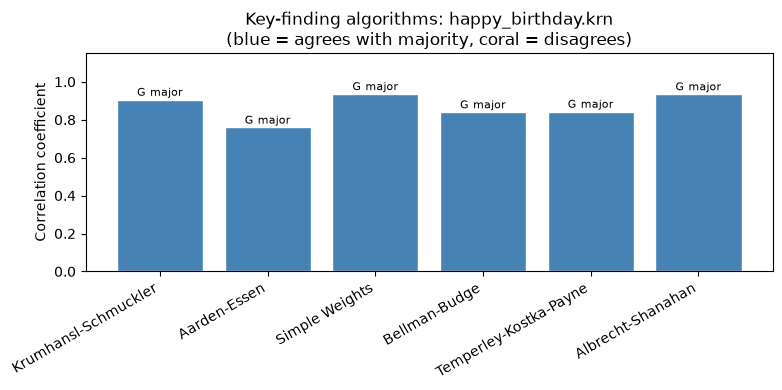

In [8]:
table = compare_keyfinding_algorithms('../data/happy_birthday.krn')

Maybe we could compare with a more difficult piece...

Here's the Chopin A-Minor _Prélude_ (op.28. no.2):

prelude28-02.krn: 2 unique key answer(s) across 6 algorithm(s). Majority answer: a minor.


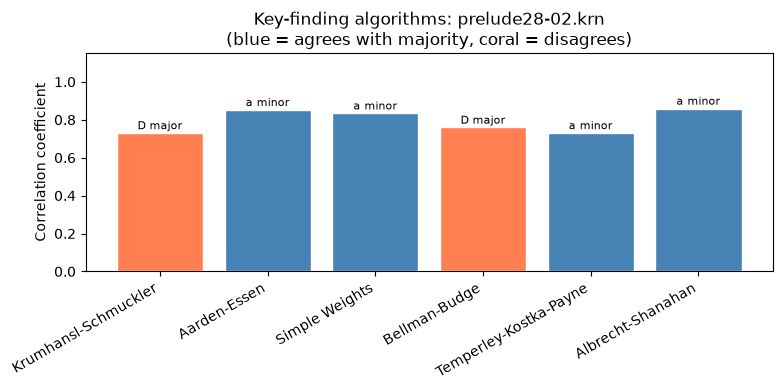

In [9]:
table = compare_keyfinding_algorithms('../data/humdrum_scores/Chopin/Preludes/prelude28-02.krn')

In [10]:
from utils import bach_chorale_key_table
import pandas as pd
table = bach_chorale_key_table()
table
## save as a CSV file
#table.to_csv('../data/bach_chorale_key_table.csv', index=False)

  Analyzing 1/370...
  Analyzing 51/370...
  Analyzing 101/370...
  Analyzing 151/370...
  Analyzing 201/370...
  Analyzing 251/370...
  Analyzing 301/370...
  Analyzing 351/370...
Analyzed 370 chorale(s).


,tune_id,annotated_key,Krumhansl-Schmuckler,Aarden-Essen,Simple Weights,Bellman-Budge,Temperley-Kostka-Payne,Albrecht-Shanahan
0,chor001,G major,G major (0.95),G major (0.95),G major (0.97),G major (0.97),G major (0.97),G major (0.99)
1,chor002,A major,E major (0.85),A major (0.96),A major (0.92),A major (0.95),A major (0.94),A major (0.92)
2,chor003,A dorian,A minor (0.77),A minor (0.89),A minor (0.91),A minor (0.95),A minor (0.91),A minor (0.95)
3,chor004,E major,E major (0.89),E major (0.91),E major (0.95),E major (0.93),E major (0.91),E major (0.95)
4,chor005,G major,G major (0.89),G major (0.93),G major (0.94),G major (0.93),G major (0.93),G major (0.93)
...,...,...,...,...,...,...,...,...
365,chor367,B minor,B minor (0.90),B minor (0.94),B minor (0.86),D major (0.81),D major (0.87),B minor (0.88)
366,chor368,F major,F major (0.96),F major (0.94),F major (0.98),F major (0.97),F major (0.98),F major (0.99)
367,chor369,B- dorian,B- minor (0.82),B- minor (0.97),B- minor (0.94),B- minor (0.92),B- minor (0.93),B- minor (0.96)
368,chor370,A minor,A minor (0.83),A minor (0.95),A minor (0.96),A minor (0.94),A minor (0.93),A minor (0.98)


  Analyzing 1/370...
  Analyzing 26/370...
  Analyzing 51/370...
  Analyzing 76/370...
  Analyzing 101/370...
  Analyzing 126/370...
  Analyzing 151/370...
  Analyzing 176/370...
  Analyzing 201/370...
  Analyzing 226/370...
  Analyzing 251/370...
  Analyzing 276/370...
  Analyzing 301/370...
  Analyzing 326/370...
  Analyzing 351/370...


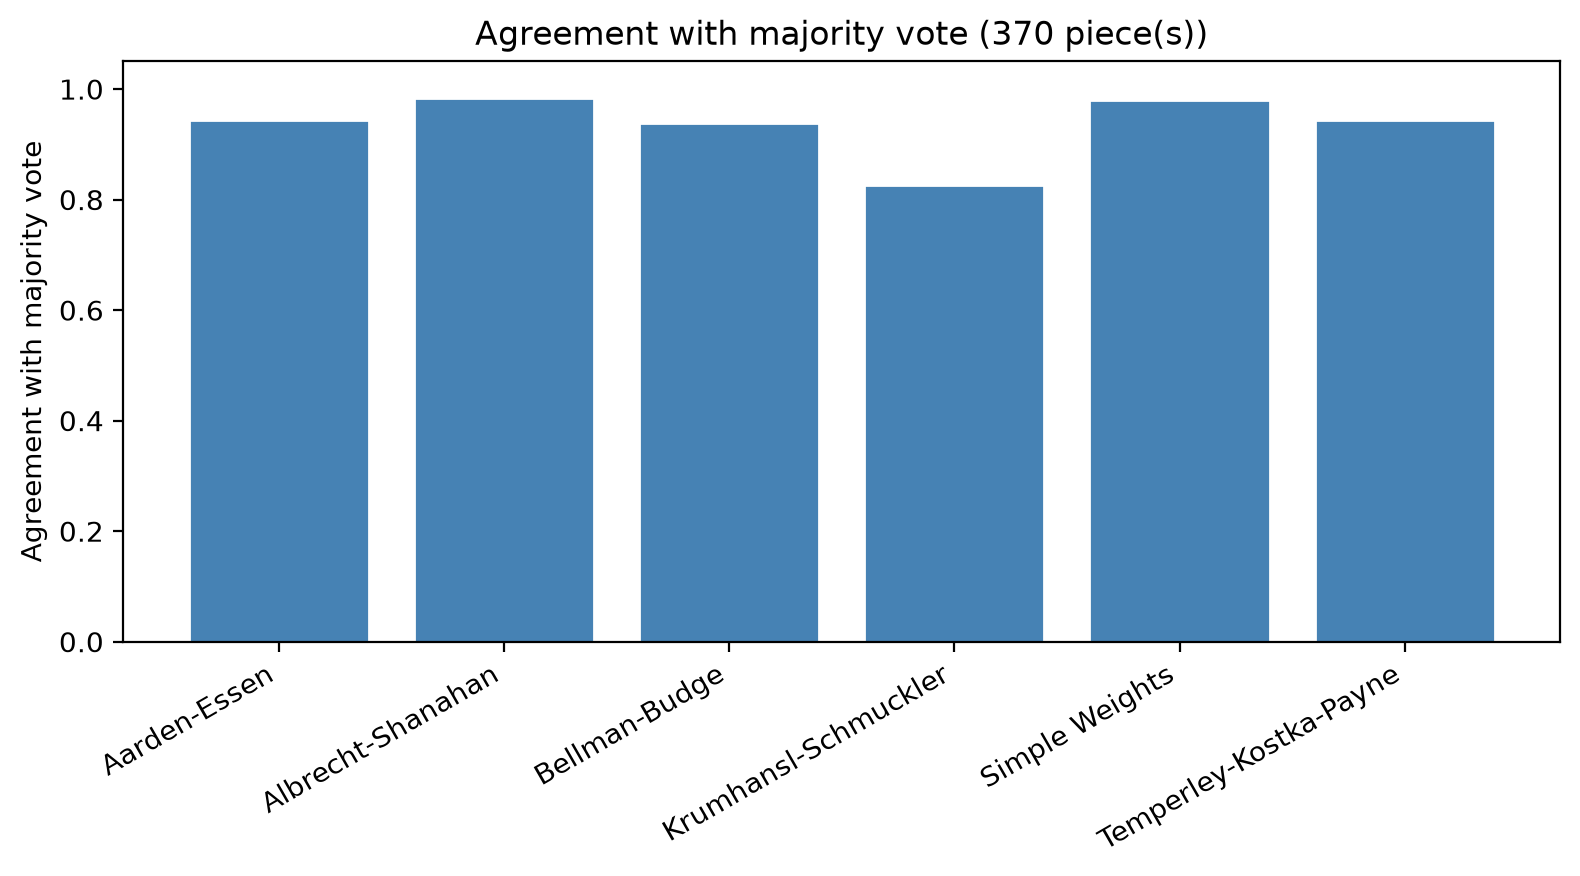

In [31]:
results, summary = compare_keyfinding_corpus(
    '../data/humdrum_scores/Bach/Chorales/371chorales',
    pattern='chor*.krn',
    ground_truth=ground_truth
)

# Making your own algorithm

We could also make our own algorithms, either trained on data or modified from others. The process will go as follows:


## Trained from a corpus

1. Load a corpus and get ratings from the corpus (this normalizes to a single key that was assigned with ground truth)
2. Use those ratings to construct the new algorithm.

## Modified from another corpus
1. Create a variable from another profile, and adjust them individually. 


Let's look how each works. 

## Training from a corpus

We have a few helper functions for this. The first is to load 

In [ ]:
from utils import load_keys_from_title, compare_keyfinding_corpus, train_key_profile

ground_truth = load_keys_from_title('../data/humdrum_scores/Beethoven')
results, summary = compare_keyfinding_corpus('../data/humdrum_scores/Beethoven', ground_truth=ground_truth)
my_beethoven_profile = train_key_profile('../data/humdrum_scores/Beethoven', ground_truth)

Found a key in the title for 58/58 file(s).
No pieces could be analyzed.
Trained on 58 piece(s): 40 major, 18 minor.


Now that we've gotten the profile, we can see how they're all weighted. 

In [ ]:
print(my_beethoven_profile)

{'major': [0.1483461139743995, 0.03115143405409777, 0.11706969186768912, 0.034901075632476304, 0.11045267731760934, 0.10711476108901355, 0.03159256835743642, 0.1497871526986391, 0.04014322160381728, 0.1024534419504018, 0.04895855543220133, 0.07802930602221847], 'minor': [0.14145512086728165, 0.041192512288734766, 0.09507777254056966, 0.10842704195003704, 0.05151168271496869, 0.1034778802774224, 0.027136219783179583, 0.15333984243485288, 0.0865766615042758, 0.045720826880344755, 0.09401723789643796, 0.05206720086189482]}


And now we can use our "make_key_algorithm" to train it, and then test it on a piece.

In [ ]:
from utils import load_piece, make_key_algorithm

MyBeethoven = make_key_algorithm(
    my_beethoven_profile['major'], 
    my_beethoven_profile['minor'], 
    name='My Beethoven Profile'
)
score = load_piece('../data/humdrum_scores/Beethoven/Quartets.Str/quartet01-1.krn')
key = MyBeethoven().getSolution(score)
print(key, key.correlationCoefficient)

F major 0.9196800838697314


### Option 2: Manually building an algorithm

You can put your own numbers in, much like Craig Sapp did with the Simple Weightings. 

Here, my random numbers really mess up "Happy Birthday"...

In [ ]:
from utils import load_piece, make_key_algorithm

major = [5, 0, 2, 1, 4, 4, 5, 0, 2, 0, 1, 3]
minor = [5, 0, 2, 4, 1, 4, 5, 1, 2, 2, 2, 3]
MyAlgorithm = make_key_algorithm(major, minor, name='My Profile')

score = load_piece('../data/happy_birthday.krn')   # parse first
key = MyAlgorithm().getSolution(score)
print(key, key.correlationCoefficient)

D major 0.45071606504889


You could also take a profile and adjust it. Here is one that takes the Kruhmansl-Schmuckler algorithm and emphasizes the fifth scale degree.

In [ ]:
from utils import get_key_profile
profile = get_key_profile('Krumhansl-Schmuckler')   # or pass the class itself
my_major = profile['major'][:]   # copy it so editing is safe
my_major[7] *= 1.5               # e.g. exaggerate the fifth
print(my_major)

[6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 7.785, 2.39, 3.66, 2.29, 2.88]


# Keyscapes

One useful way of seeing what's happening with a key-finding algorithm within a piece is by looking at "keyscapes". 

These show varying windows of key-judgments throughout a piece. The code below uses the Aarden-Essen algorithm on Happy Birthday. 

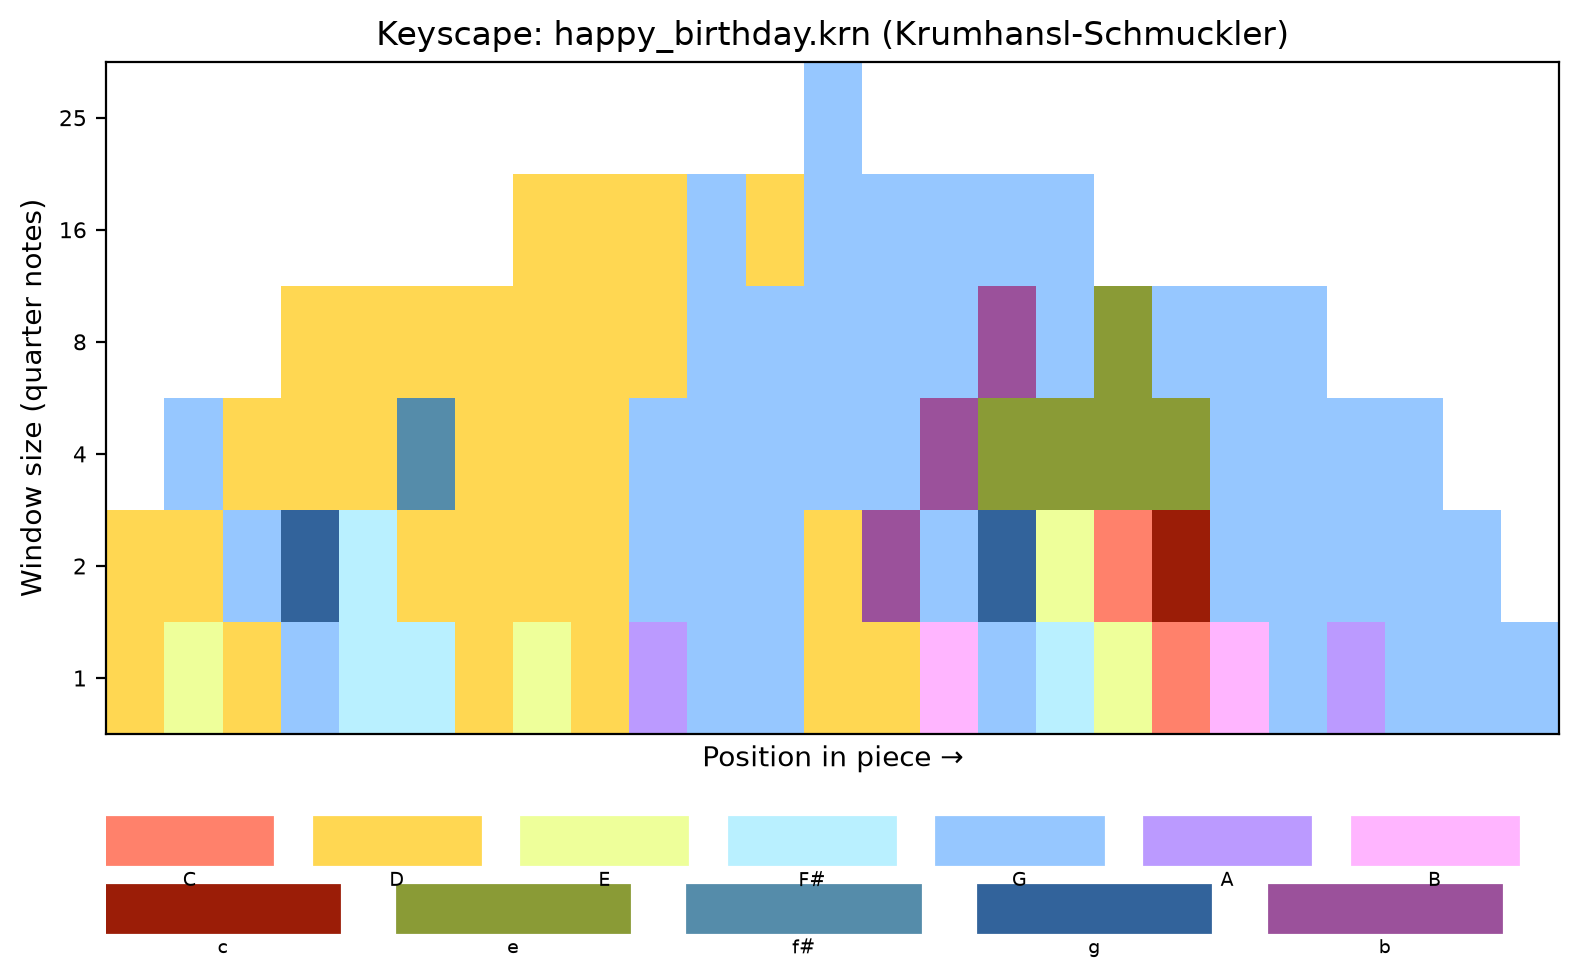

In [36]:
from utils import keyscape, compare_keyscapes

keyscape('../data/happy_birthday.krn');



We can also compare what's happening with each algorithm with our compare_keyscapes function.

/Users/danielshanahan/Downloads/huji_summer_class_2026/notebooks/../utils/keyfinding.py:1248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0.08, 1, 1))


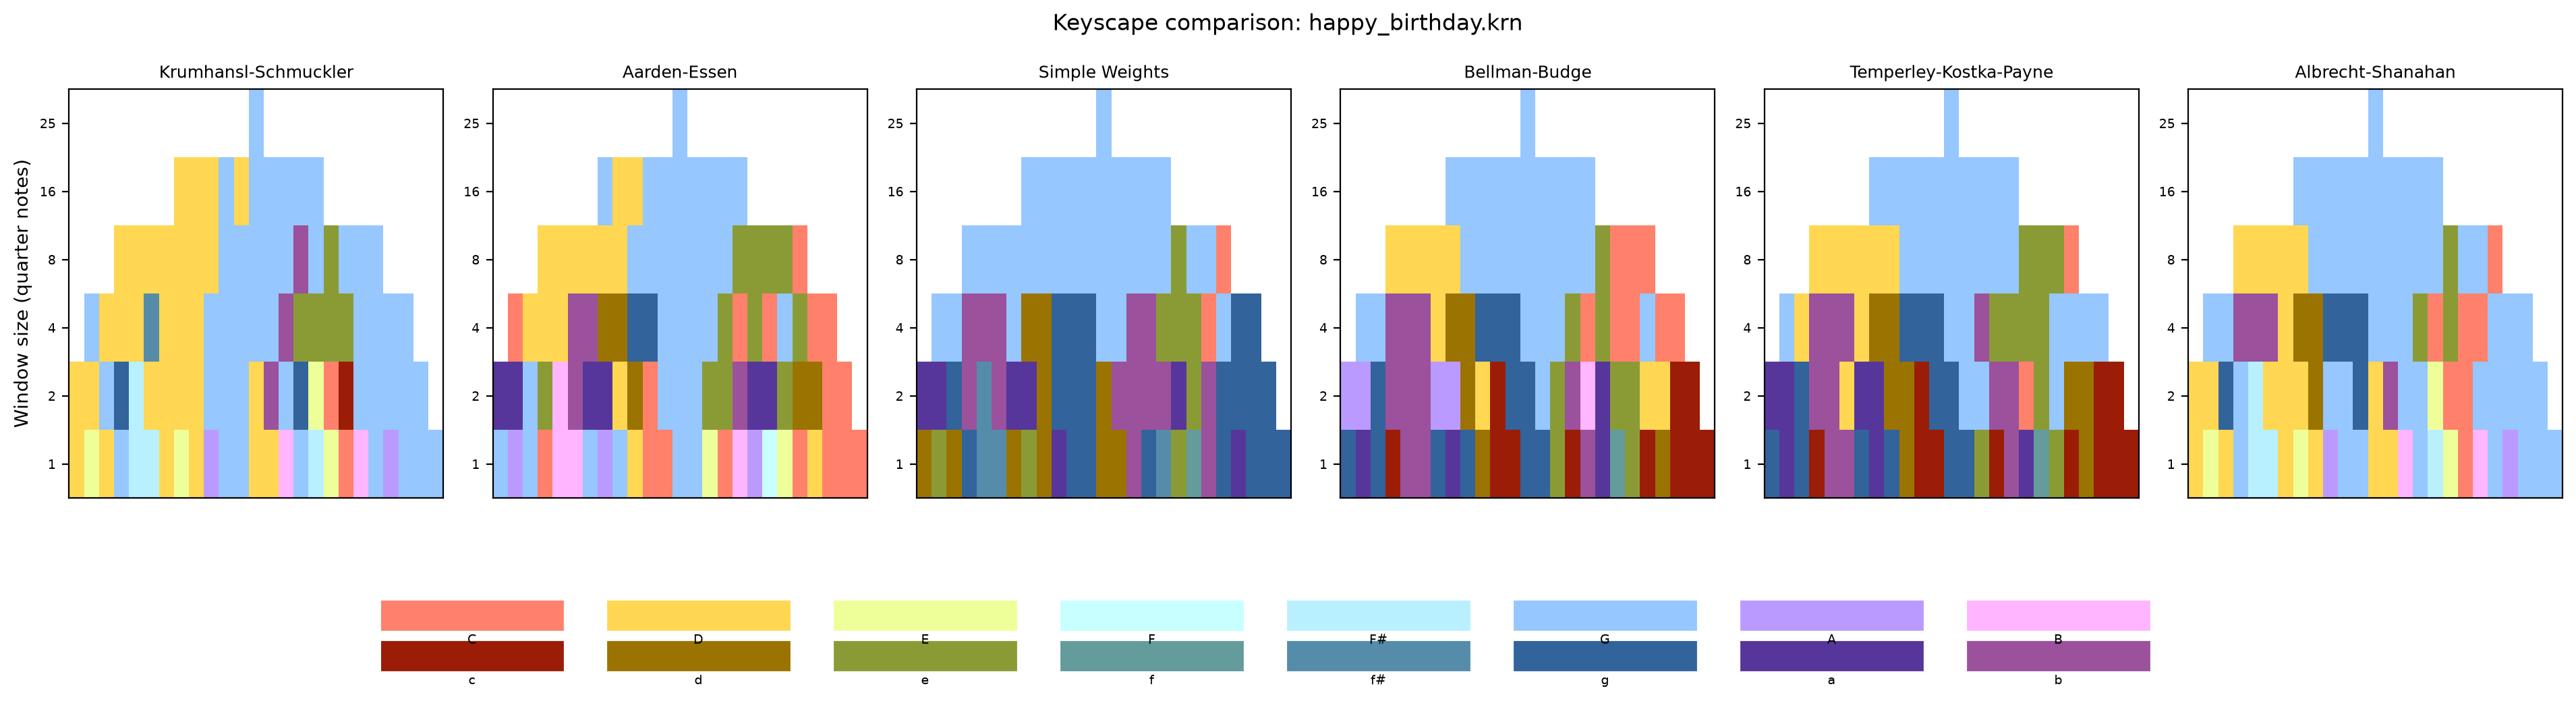

In [35]:
compare_keyscapes('../data/happy_birthday.krn');   # compares all 6 algorithms


## Changing the Window Sizes

We can look at how the perception of key changes based on the size of the window we are analyzing, as well...

Play with the window size argument below and see how the perception of the key changes...

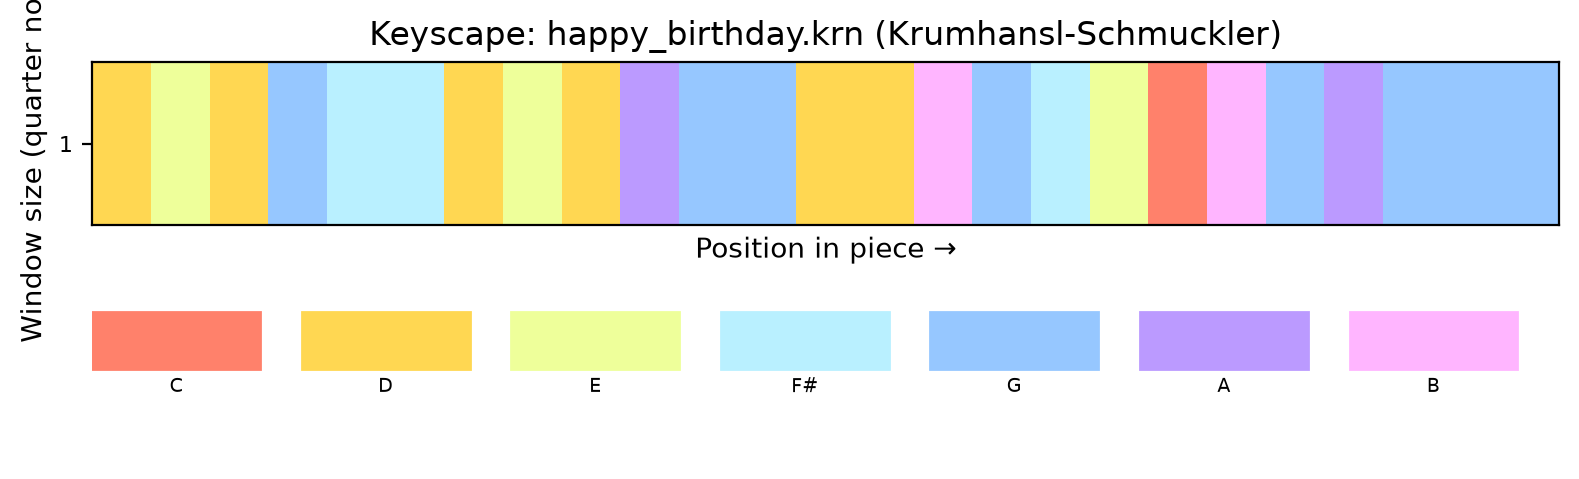

In [34]:
from utils import keyscape, compare_keyscapes

# single algorithm, one fixed 8-beat window (a strip, not a triangle)
keyscape('../data/happy_birthday.krn', window_size=1);


And again, we can compare with different window sizes:

/Users/danielshanahan/Downloads/huji_summer_class_2026/notebooks/../utils/keyfinding.py:1248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0.08, 1, 1))


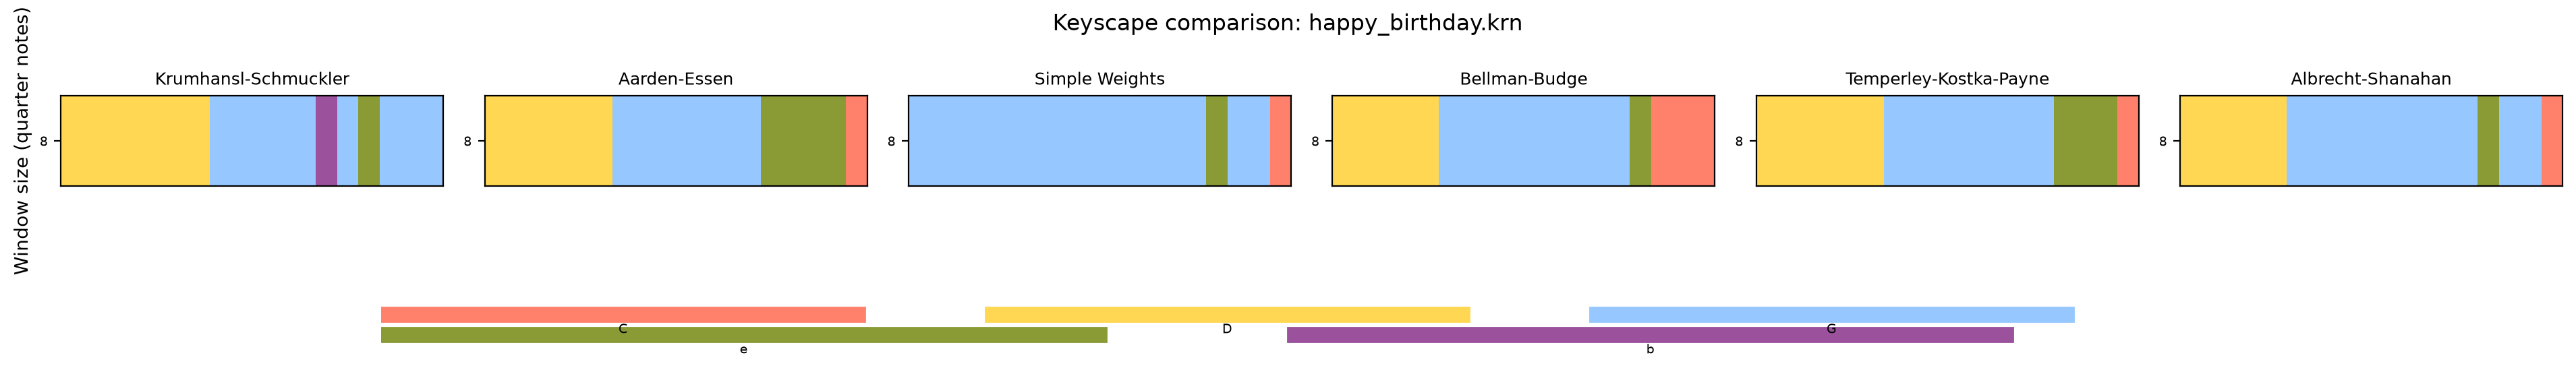

In [33]:

# compare all 6 default algorithms at that same fixed window
compare_keyscapes('../data/happy_birthday.krn', window_size=8);


# Testing Accuracy with Chi-Square, T-Tests, and More

Let's return to our empirical approaches! How do we know if these are truly performing better?

We can return to our chi-square for a first pass!

  Analyzing 1/43...
  Analyzing 26/43...


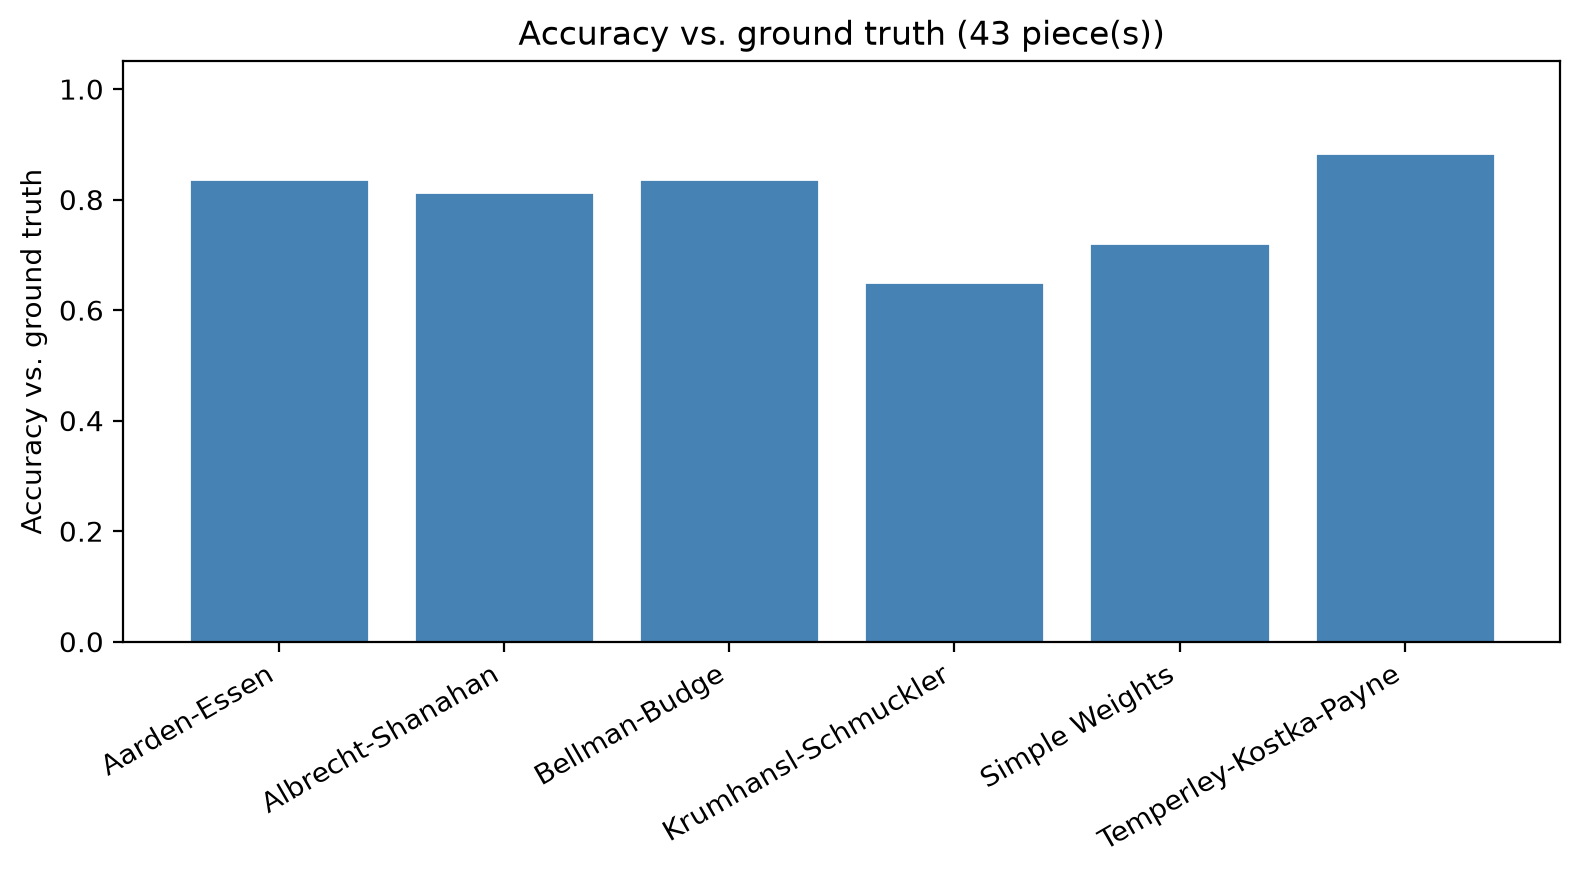

Chi-square test of independence — accuracy (both_correct) vs. algorithm:
  chi2 = 9.837, dof = 5, p = 0.0800
  -> p >= 0.05: no significant evidence that accuracy differs by algorithm.


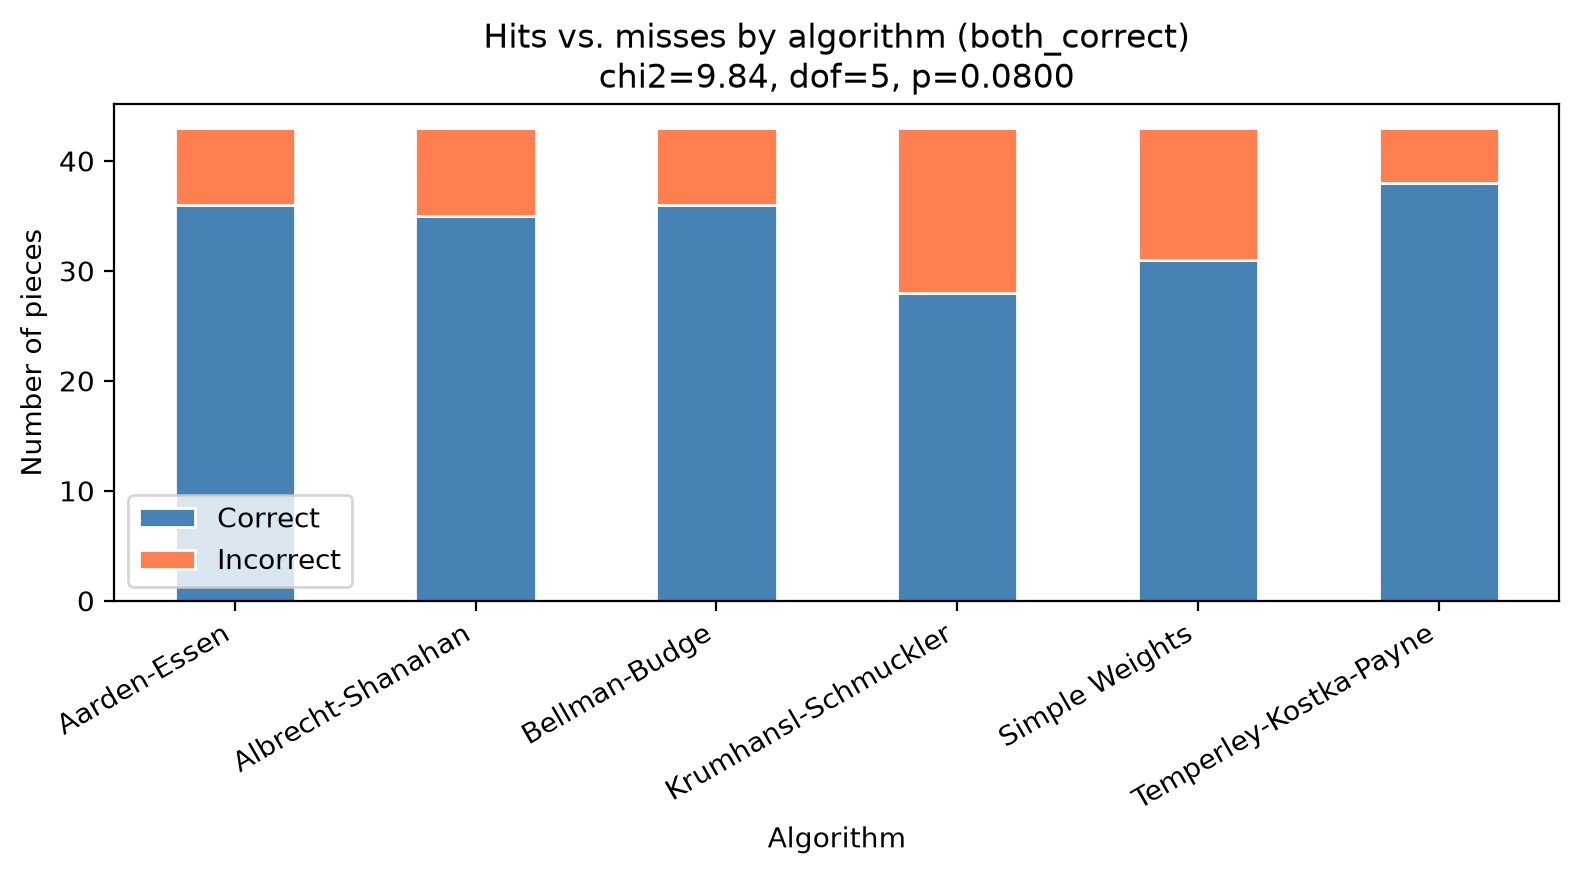

In [14]:
from utils import load_essen_keys, compare_keyfinding_corpus
from utils import chi_square_accuracy, ttest_algorithm_correlations, compare_algorithms_anova

ground_truth = load_essen_keys('../data/essen_keys.csv')
results, summary = compare_keyfinding_corpus('../data/Essen/Czech', ground_truth=ground_truth)
table, chi2, p, dof = chi_square_accuracy(results)
# Chi-square test of independence — accuracy (both_correct) vs. algorithm:
#   chi2 = 5.455, dof = 5, p = 0.3630
#   -> p >= 0.05: no significant evidence that accuracy differs by algorithm.

## Comparing with a T-Test

A t-test is used to see if two distributions differ signficantly from one another. Here we can see that there is no significant difference with the Czech folksongs. 

Note that I cannot say that it is "almost significant"!!! It is or it isn't.

Paired t-test: Krumhansl-Schmuckler (mean=0.789) vs. Albrecht-Shanahan (mean=0.803)
  t = -1.996, p = 0.0524
  -> p >= 0.05: no significant difference detected.


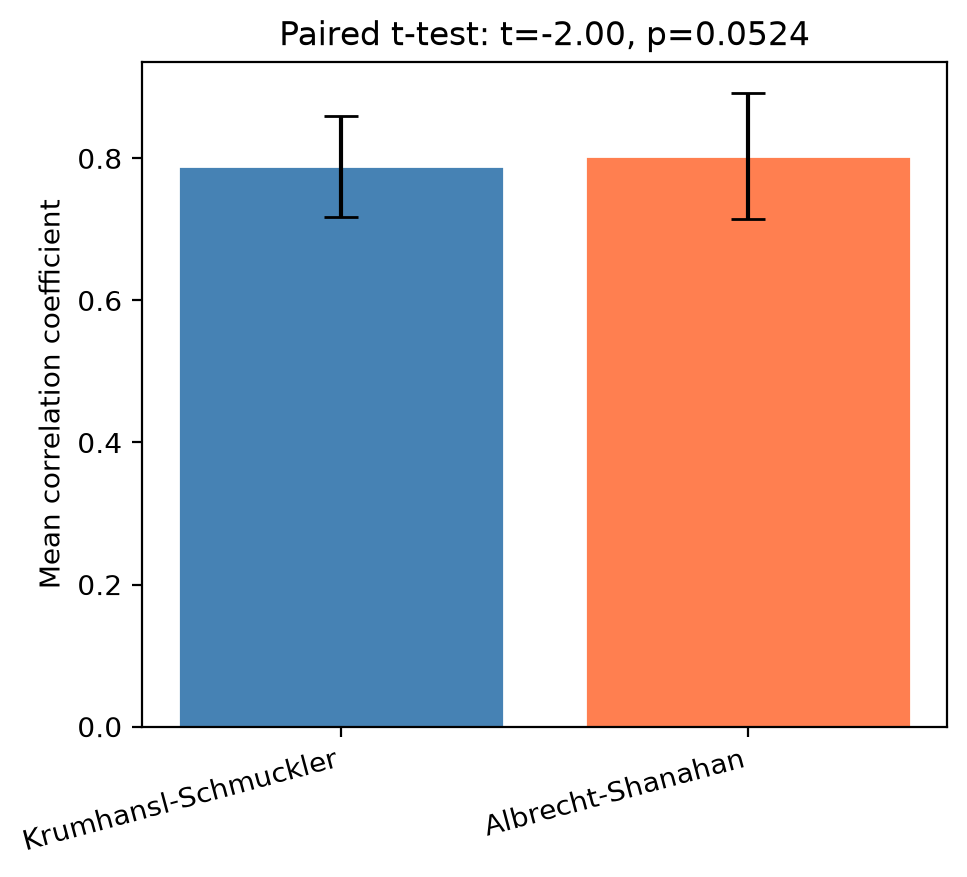

In [15]:
t, p, mean_a, mean_b = ttest_algorithm_correlations(
    results, 'Krumhansl-Schmuckler', 'Albrecht-Shanahan')
# Paired t-test: Krumhansl-Schmuckler (mean=0.840) vs. Albrecht-Shanahan (mean=0.901)
#   t = -2.30, p = 0.0612

# Analysis of Variance

We can see if there's any difference in the variance here of each of these algorithms, as well with an ANOVA.

One-way ANOVA on 'correlation' across 6 algorithm(s):
  statistic = 0.940, p = 0.4555
  -> p >= 0.05: no significant overall difference detected.


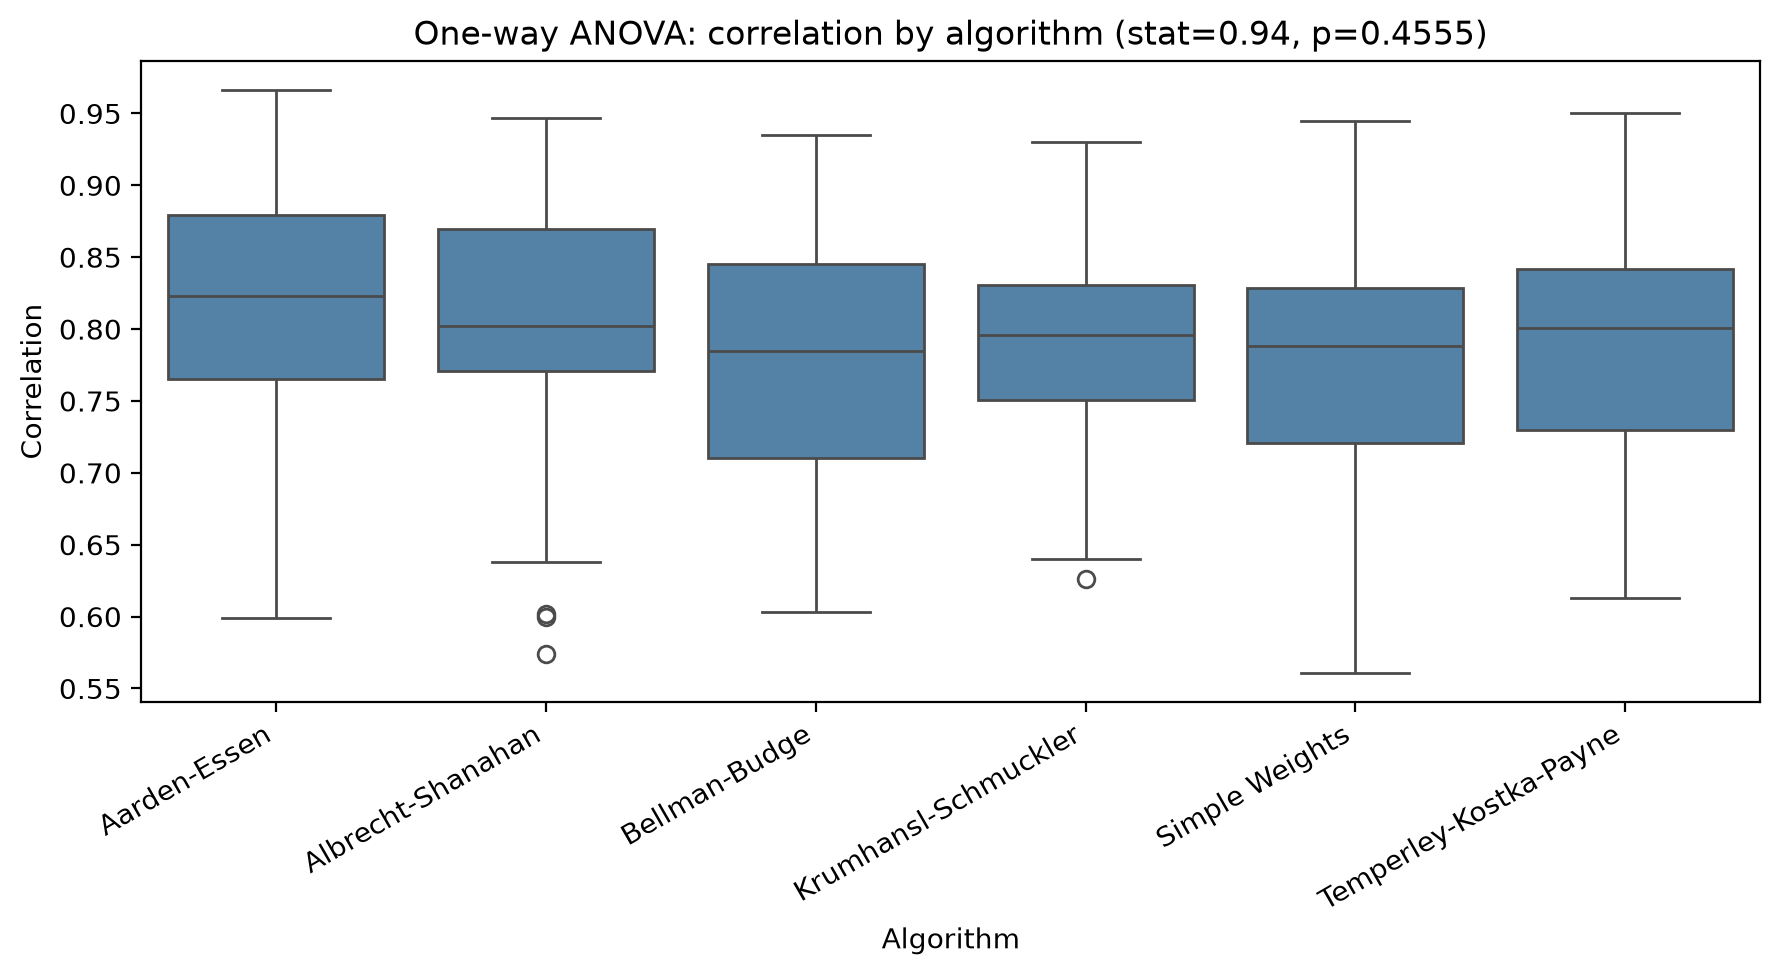

Kruskal-Wallis on 'correlation' across 6 algorithm(s):
  statistic = 5.309, p = 0.3793
  -> p >= 0.05: no significant overall difference detected.


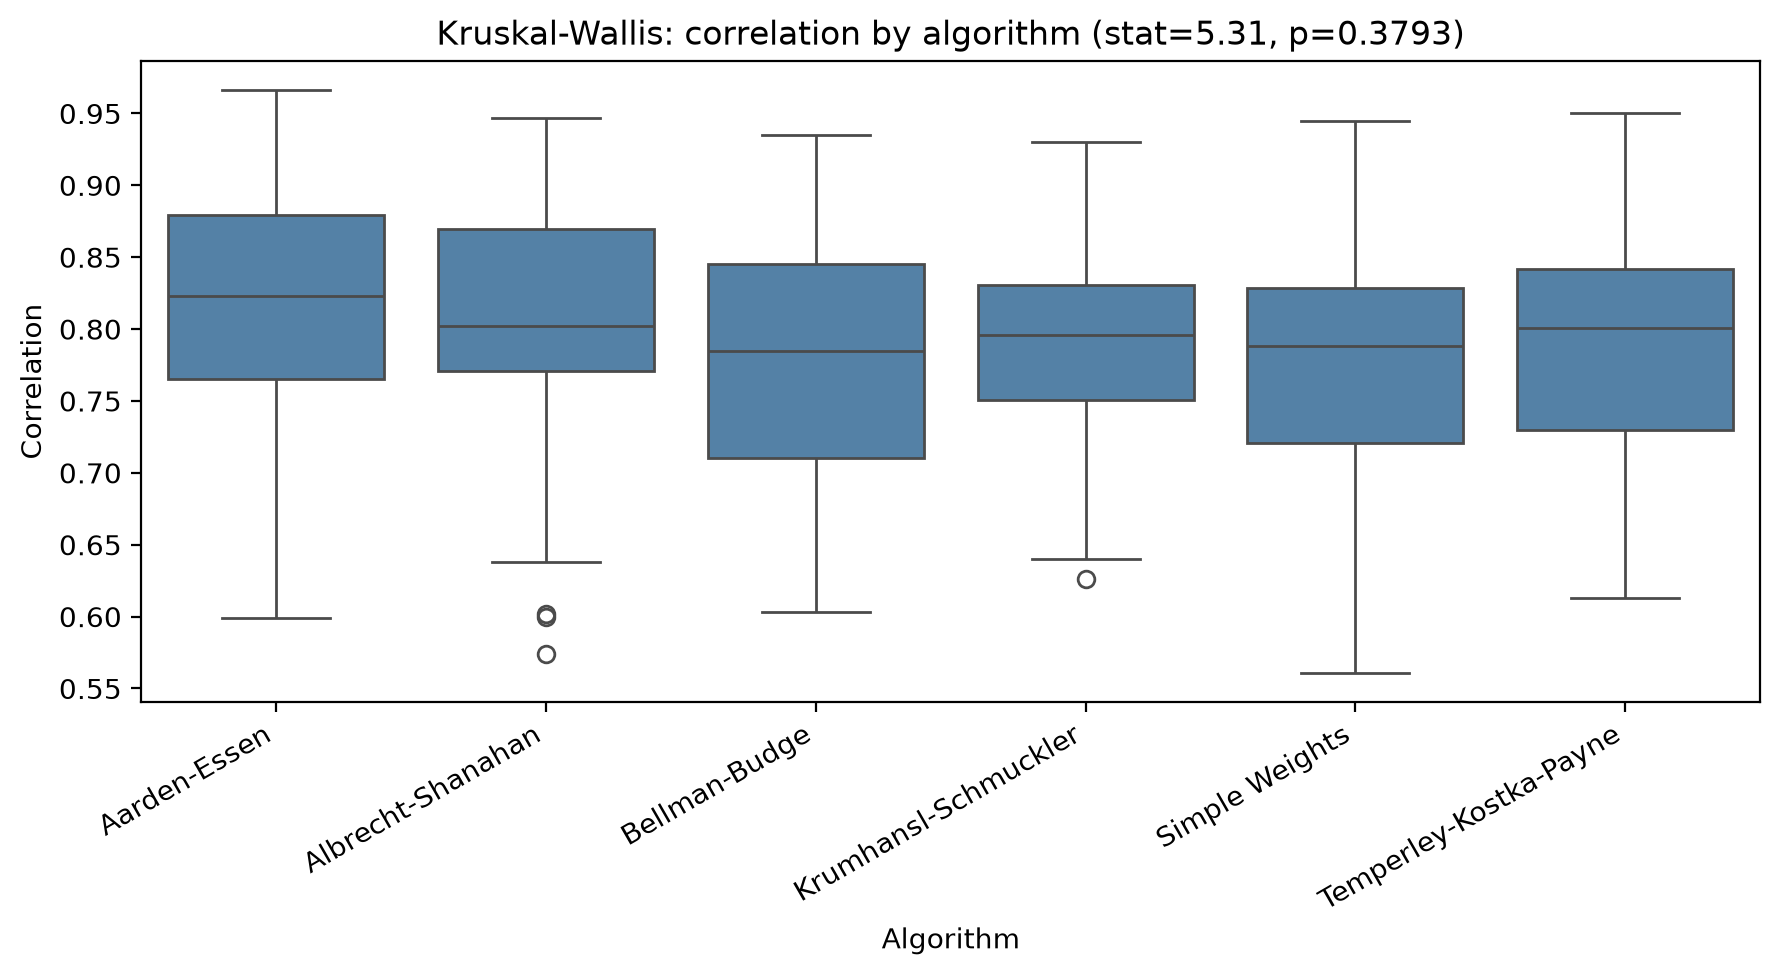

In [16]:
stat, p = compare_algorithms_anova(results)               # one-way ANOVA
stat, p = compare_algorithms_anova(results, method='kruskal')  # non-parametric version

# Empirical Test: Bach Key-Profiles, Chopin, and Beethoven

H1: A key-finding algorithm trained on Bach's music will perform better on Chopin than on Beethoven.
H0: There is no signficant difference between the performances.

Chopin accuracy:    83.3%
Beethoven accuracy: 50.0%


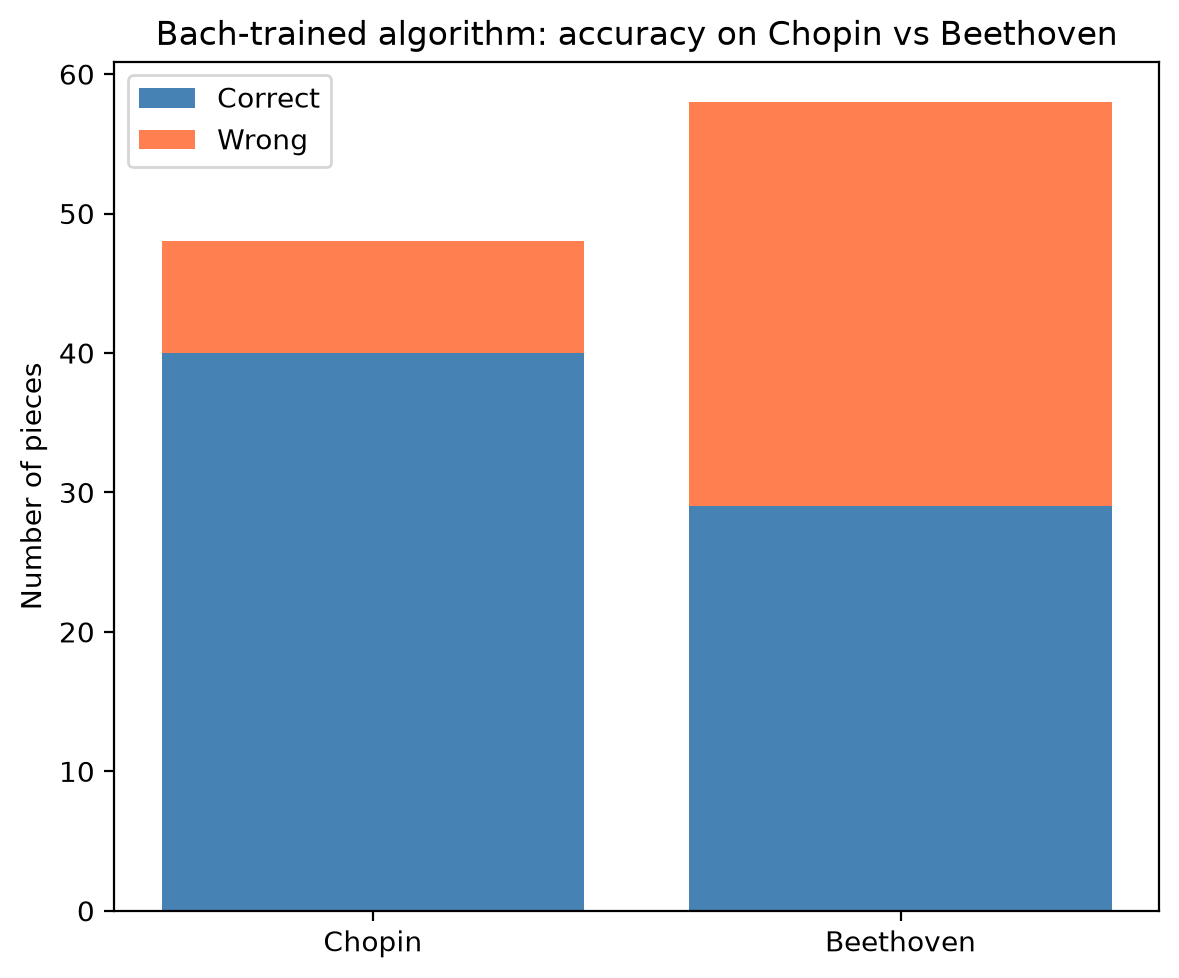


Chi-square: chi2=11.418, p=0.0007
H1 supported


In [29]:
# H1: A key-finding algorithm trained on Bach will perform better on Chopin than Beethoven
# H0: No significant difference

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Results
chopin_accuracy = chopin_results['both_correct'].mean()
beeth_accuracy  = beeth_results['both_correct'].mean()
print(f'Chopin accuracy:    {chopin_accuracy:.1%}')
print(f'Beethoven accuracy: {beeth_accuracy:.1%}')

# Stacked bar plot
chopin_correct   = chopin_results['both_correct'].sum()
chopin_wrong     = (~chopin_results['both_correct']).sum()
beeth_correct    = beeth_results['both_correct'].sum()
beeth_wrong      = (~beeth_results['both_correct']).sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Chopin', 'Beethoven'], [chopin_correct, beeth_correct],
       label='Correct', color='steelblue')
ax.bar(['Chopin', 'Beethoven'], [chopin_wrong, beeth_wrong],
       bottom=[chopin_correct, beeth_correct],
       label='Wrong', color='coral')
ax.set_ylabel('Number of pieces')
ax.set_title('Bach-trained algorithm: accuracy on Chopin vs Beethoven')
ax.legend()
plt.tight_layout()
plt.show()

# Chi-square test
ct = pd.DataFrame({
    'Chopin':    [chopin_correct, chopin_wrong],
    'Beethoven': [beeth_correct,  beeth_wrong]
}, index=['correct', 'wrong'])

chi2, p, dof, _ = chi2_contingency(ct)
print(f'\nChi-square: chi2={chi2:.3f}, p={p:.4f}')
print('H1 supported' if p < 0.05 else 'H1 not supported')

In [30]:
from scipy.stats import ttest_rel

# Paired t-test: are Chopin correlation scores higher than Beethoven?
# Paired because... wait, these are different pieces so it's actually unpaired

from scipy.stats import ttest_ind

t, p = ttest_ind(chopin_results['correlation'], 
                 beeth_results['correlation'])

print(f'Mean correlation — Chopin:    {chopin_results["correlation"].mean():.3f}')
print(f'Mean correlation — Beethoven: {beeth_results["correlation"].mean():.3f}')
print(f't = {t:.3f}, p = {p:.4f}')

Mean correlation — Chopin:    0.856
Mean correlation — Beethoven: 0.920
t = -5.396, p = 0.0000


# Email to Dan, Day 3

What are your thoughts on key-finding algorithms? Are they useful as a way of modeling perception? Is it more utilitarian ("I have thousands of pieces that need key signatures!")? What can we learn? Is there more to learn?
